In [ ]:
from IPython.display import Audio
a = Audio('Jaime_24.wav') # asi se toma un audio
a #asi se reproduce

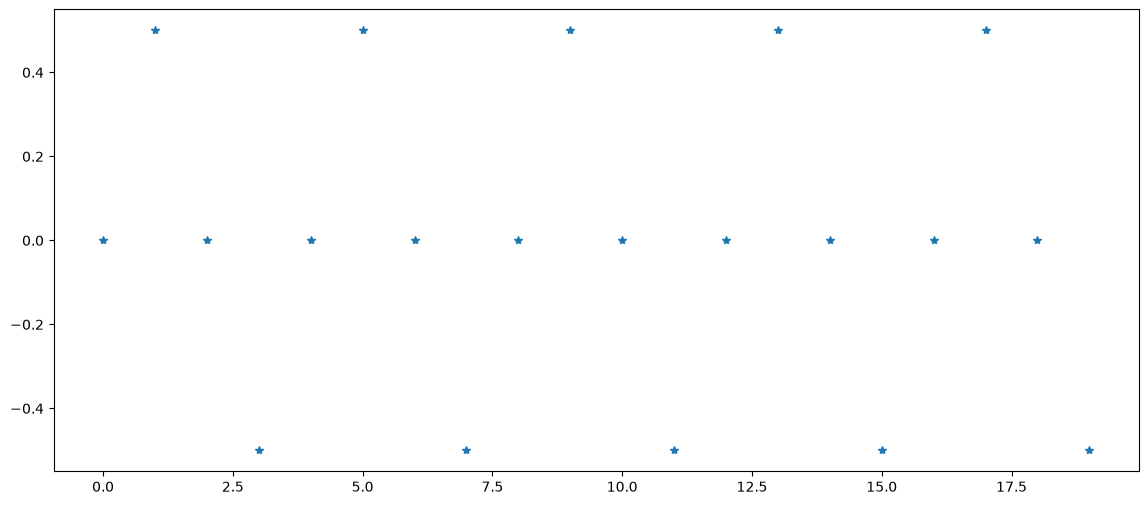

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#Ejemplo

# Voy a muestrear a 200 muestras por segundo durante 0.1 segundos (5 períodos de una sinusoide de período 
# 1/50 segundos). Necesito un vector con los tiempos de muestreo.
T= np.arange(0,0.1,1/200) # esta instrucción crea un vector de 0 a 0.1 con pasos de 1/200 = 0.05
# Por ejemplo, genero una sinusoide de frecuencia 50Hz (1Hz = 1 ciclo o período por segundo, 
# es decir de período 1/50 segundos) muestreada en los tiempos correspondientes al vector T,
# y la asigno a un vector f1
f0 = 50
amplitud = 0.5
f1 = amplitud * np.sin(2*np.pi*f0*T)
# Represento gráficamente el vector f1 poniendo en cada muestra un "*"
# Observar que para dibujar la gráfica le pedimos a la función plot que los puntos los muestre con un '*'. 
# Si no ponemos este parámetro, plot unirá los puntos con líneas y podremos no darnos cuenta dónde 
# están las muestras. Pruebe a hacerlo.
plt.figure(figsize=(14,6))
plt.plot(f1, "*")
plt.show()

In [3]:
import numpy as np
from IPython.display import Audio
fs = 44100 # Tasa/frecuencia de muestreo.
T = 2.0    # Tiempo de muestreo de la señal.
t = np.arange(0, T, 1/fs) # Vector con los tiempos de muestreo.
f0 = 440 # Frecuencia de la sinusoide.
x = 0.5*np.sin(2*np.pi*f0*t) # Nota La de la cuarta octava, una sinusoide(tono) a 440 Hz.
# Para escuchar el audio en este caso no tenemos un archivo como antes, sino el array con las muestras.
# A la función Audio le podemos pasar el array con las muestras directamente y la tasa de muestreo 
# en el parámetro rate.
Audio(x, rate=fs)
# Probar variar la frecuencia de la sinusoide, por ejemplo a 5000 Hz y a 100 Hz, y ver qué se escucha.

# Fast Fourier Transform

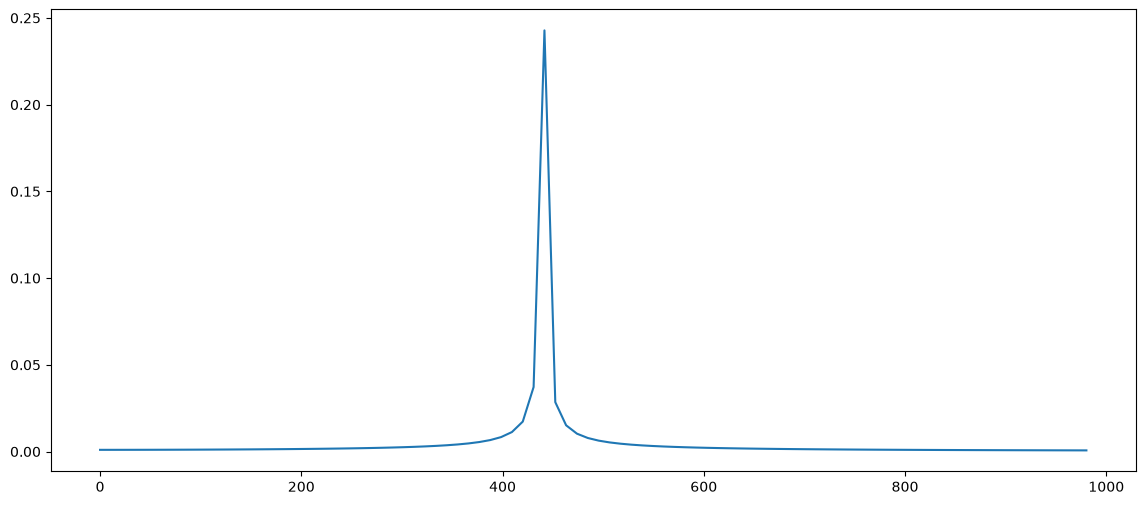

In [4]:
#Fast Fourier Transform

import numpy as np
import matplotlib.pyplot as plt
def plot_frec(x,fs,fmax,m): 
    # esta función permite graficar las frecuencias de una señal x muestreada a tasa fs, 
    # el rango que grafica va hasta fmax, y m la  cantidad de puntos que toma para calcular la FFT .
    
    #x será la funcion senoidal o señal, fmax una frecuencia maxima
    
    puntos = int((fmax/fs)*m)
    long = len(x)
    nt = (long + m - 1)//m
    
    xp = np.append(x,np.zeros(-long+nt*m))
    xmw = np.reshape( xp, (m,nt), order='F')
    xmf = np.fft.fft(xmw,len(xmw),axis=0)/m
    xf = np.linspace(0, int(fs/2.0), int(m/2))
    plt.figure(figsize=(14,6))
    plt.plot(xf[0:puntos],np.abs(xmf[0:int(m/2),0:int(long/m-1)]).mean(1)[0:puntos])
    plt.show()
  
# Ejemplo de como utilizar la función que muestra las componentes en frecuencia de una 
# señal usando el tono con la nota La que generamos en el ejemplo anterior
fs = 44100 # tasa de muestreo
T = 2.0    # tiempo de muestreo de la señal
t = np.arange(0, T, 1/fs) # vector con los tiempos de muestreo
f0 = 440 # frecuencia de la sinusoide
x = 0.5*np.sin(2*np.pi*f0*t) # nota La de la cuarta octava, una sinusoide(tono) a 440 Hz
#llamo a la figura y le pido que muestre los primeros 1000 Hz
plot_frec(x,fs,1000,4096)

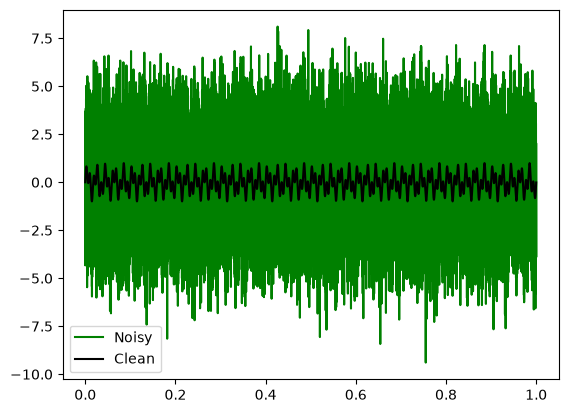

In [5]:
import numpy as np
import matplotlib.pyplot as plt

#una señal simple
fs=44100
t=np.arange(0,1,1/fs)
f=0.5*np.sin(2*np.pi*50*t)+0.5*np.sin(2*np.pi*120*t) 

f_clean=f

f=f+2*np.random.randn(len(t)) #se añade random noise

plt.plot(t,f, color='g',label="Noisy")
plt.plot(t,f_clean,color='black',label="Clean")
plt.legend()

c:\Users\cesar\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\cesar\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


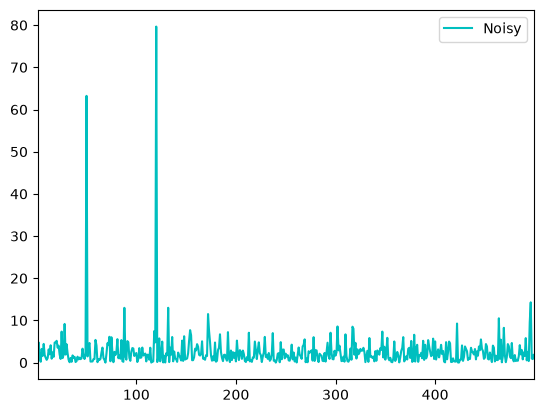

In [6]:
#Fast Fourier Transform
import numpy as np
import matplotlib.pyplot as plt

#una señal simple
fs=1000
t=np.arange(0,1,1/fs)
n=len(t)
f=0.5*np.sin(2*np.pi*50*t)+0.5*np.sin(2*np.pi*120*t) 

f_clean=f

f=f+1.5*np.random.randn(n) #se añade random noise

fhat=np.fft.fft(f, n) #complejos valores, resultados de la transformada de furier
PSD=(fhat*np.conj(fhat))/n #power spectrum density es el valor absoluto de los complejos,
                        #normalizados dividiendolos por la longitud del tiempo

freq=(fs/len(t))*np.arange(n) #si PSD es el eje y, estas frecuencias serian el eje x
L=np.arange(1,np.floor(n/2), dtype="int") #filtra el array de frecuencias, eliminando las frecuencias relativas que exiten en la segunda mitad 

PSD2=(fhat*np.conj(np.fft.fft(f_clean, n)))/n

plt.plot(freq[L],PSD[L],color="c",label="Noisy")
plt.xlim(freq[L[0]],freq[L[-1]])
plt.legend()


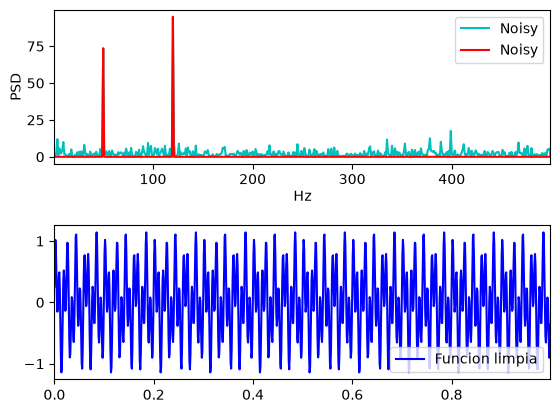

In [7]:
#Fast Fourier Transform
import numpy as np
import matplotlib.pyplot as plt

#una señal simple
fs=1000
t=np.arange(0,1,1/fs)
n=len(t)
f=0.5*np.sin(2*np.pi*50*t)+0.5*np.sin(2*np.pi*120*t) 

f_clean=f

f=f+1.5*np.random.randn(n) #se añade random noise

fhat=np.fft.fft(f, n) #complejos valores, resultados de la transformada de furier
PSD=(fhat*np.conj(fhat))/n #power spectrum density es el valor absoluto de los complejos,
                        #normalizados dividiendolos por la longitud del tiempo

freq=(fs/len(t))*np.arange(n) #si PSD es el eje y, estas frecuencias serian el eje x
L=np.arange(1,np.floor(n/2), dtype="int") #filtra el array de frecuencias, eliminando las frecuencias relativas que exiten en la segunda mitad 

fig,axs =plt.subplots(2,1)
plt.sca(axs[0])
plt.plot(freq[L],PSD[L],color="c",label="Noisy")
plt.xlim(freq[L[0]],freq[L[-1]])
plt.legend()


#Filtrar el ruido

controller=PSD>35
PSD_clean =PSD*controller
fhat=fhat*controller
ffilt=np.fft.ifft(fhat)

plt.sca(axs[0])
plt.plot(freq[L],PSD_clean[L],color="red",label="Noisy")
plt.xlim(freq[L[0]],freq[L[-1]])
plt.legend()
plt.xlabel("Hz",labelpad=2)
plt.ylabel("PSD",labelpad=2)
plt.subplots_adjust(hspace=0.4)

plt.sca(axs[1])
plt.plot(t,ffilt,color="b",label="Funcion limpia")
plt.xlim(t[0],t[-1])
plt.legend()

